# Terna electricity by source — preanalysis v0

**Domanda chiave:** come cambia tra 2023 e 2024 il peso delle diverse fonti nel mix di produzione elettrica regionale?

**Domande complementari:**
- quali regioni restano piu dipendenti dal termoelettrico?
- dove cresce di piu il fotovoltaico?
- quanto pesa l'idroelettrico nel riequilibrio 2024?


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_DIR = Path.cwd().parent
REPO_ROOT = PROJECT_DIR.parents[2]
OUT_DIR = REPO_ROOT / 'out' / 'data' / 'mart' / 'terna_electricity_by_source'

frames = []
for year in [2023, 2024]:
    path = OUT_DIR / str(year) / 'mart_mix_regioni.parquet'
    df = pd.read_parquet(path)
    frames.append(df)

mart = pd.concat(frames, ignore_index=True)
mart.head()


,anno,regione,fonte,produzione_gwh_netta,totale_regione_gwh_netta,quota_mix_regionale_pct
0,2023,Abruzzo,Termoelettrico,2205.131892,5281.527087,41.75
1,2023,Abruzzo,Idrico,1526.404018,5281.527087,28.90
2,2023,Abruzzo,Fotovoltaico,1055.211536,5281.527087,19.98
3,2023,Abruzzo,Eolico,494.779641,5281.527087,9.37
4,2023,Basilicata,Eolico,3239.106630,4790.653962,67.61


In [2]:
national = (
    mart.groupby(['anno', 'fonte'], as_index=False)['produzione_gwh_netta']
    .sum()
)
national['totale_nazionale_gwh'] = national.groupby('anno')['produzione_gwh_netta'].transform('sum')
national['quota_nazionale_pct'] = (national['produzione_gwh_netta'] / national['totale_nazionale_gwh'] * 100).round(2)

pivot_national = (
    national.pivot(index='fonte', columns='anno', values='quota_nazionale_pct')
    .fillna(0)
    .reset_index()
)
pivot_national['delta_pp_2024_vs_2023'] = (pivot_national[2024] - pivot_national[2023]).round(2)
pivot_national.sort_values('delta_pp_2024_vs_2023', ascending=False)


anno,fonte,2023,2024,delta_pp_2024_vs_2023
4,Idrico,15.89,20.21,4.32
2,Fotovoltaico,11.60,13.28,1.68
0,Accumulo Stand Alone,0.00,0.05,0.05
3,Geotermoelettrico,2.15,2.09,-0.06
1,Eolico,8.93,8.24,-0.69
5,Termoelettrico,61.42,56.13,-5.29


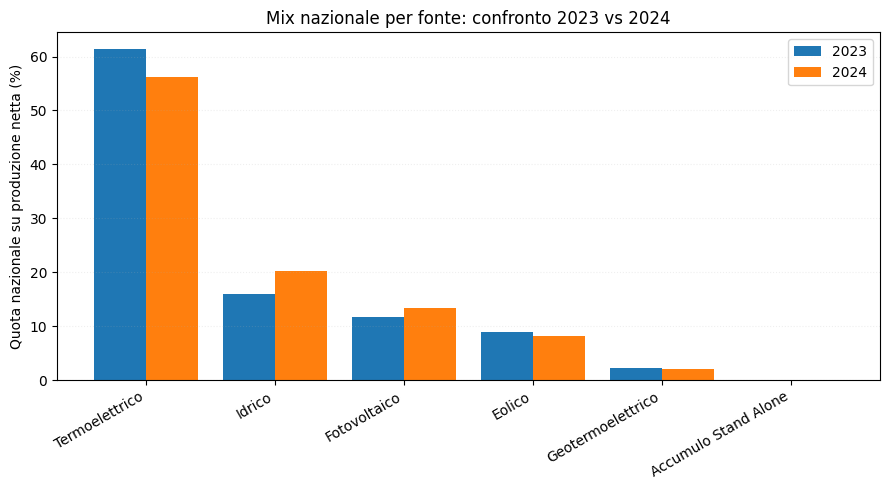

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = pivot_national.sort_values(2024, ascending=False)
x = range(len(plot_df))
ax.bar([i - 0.2 for i in x], plot_df[2023], width=0.4, label='2023')
ax.bar([i + 0.2 for i in x], plot_df[2024], width=0.4, label='2024')
ax.set_xticks(list(x))
ax.set_xticklabels(plot_df['fonte'], rotation=30, ha='right')
ax.set_ylabel('Quota nazionale su produzione netta (%)')
ax.set_title('Mix nazionale per fonte: confronto 2023 vs 2024')
ax.legend()
ax.grid(axis='y', alpha=0.2, linestyle=':')
plt.tight_layout()
plt.show()


In [4]:
regional = mart.pivot(index=['regione', 'fonte'], columns='anno', values='quota_mix_regionale_pct').reset_index()
regional = regional.rename(columns={2023: 'quota_2023', 2024: 'quota_2024'})
regional[['quota_2023', 'quota_2024']] = regional[['quota_2023', 'quota_2024']].fillna(0)
regional['delta_pp'] = (regional['quota_2024'] - regional['quota_2023']).round(2)

top_up = regional.sort_values('delta_pp', ascending=False).head(10)
top_down = regional.sort_values('delta_pp', ascending=True).head(10)

display(top_up)
display(top_down)


anno,regione,fonte,quota_2023,quota_2024,delta_pp
49,Molise,Termoelettrico,39.45,58.37,18.92
16,Campania,Termoelettrico,44.33,59.73,15.40
29,Lazio,Fotovoltaico,20.72,34.09,13.37
25,Friuli-Venezia Giulia,Idrico,20.05,32.34,12.29
53,Piemonte,Idrico,22.02,31.80,9.78
3,Abruzzo,Termoelettrico,41.75,49.89,8.14
43,Marche,Fotovoltaico,59.23,67.31,8.08
40,Lombardia,Idrico,19.42,26.41,6.99
93,Veneto,Idrico,24.08,30.02,5.94
67,Sicilia,Fotovoltaico,13.08,18.85,5.77


anno,regione,fonte,quota_2023,quota_2024,delta_pp
26,Friuli-Venezia Giulia,Termoelettrico,70.13,52.94,-17.19
46,Molise,Eolico,38.05,25.42,-12.63
31,Lazio,Termoelettrico,68.30,56.20,-12.10
13,Campania,Eolico,36.87,25.41,-11.46
69,Sicilia,Termoelettrico,66.24,55.63,-10.61
54,Piemonte,Termoelettrico,68.68,58.19,-10.49
44,Marche,Idrico,21.00,10.73,-10.27
2,Abruzzo,Idrico,28.90,20.07,-8.83
41,Lombardia,Termoelettrico,73.13,65.78,-7.35
94,Veneto,Termoelettrico,56.52,49.82,-6.70


In [5]:
termo = pivot_national.loc[pivot_national['fonte'] == 'Termoelettrico'].iloc[0]
idrico = pivot_national.loc[pivot_national['fonte'] == 'Idrico'].iloc[0]
foto = pivot_national.loc[pivot_national['fonte'] == 'Fotovoltaico'].iloc[0]

top_termo_up = regional[regional['fonte'] == 'Termoelettrico'].sort_values('delta_pp', ascending=False).iloc[0]
top_termo_down = regional[regional['fonte'] == 'Termoelettrico'].sort_values('delta_pp', ascending=True).iloc[0]
top_foto_up = regional[regional['fonte'] == 'Fotovoltaico'].sort_values('delta_pp', ascending=False).iloc[0]

summary = f"""
## Risposta sintetica v0

A livello nazionale, tra 2023 e 2024 il mix di produzione netta si sposta in modo leggibile:

- **Termoelettrico**: {termo[2023]:.2f}% -> **{termo[2024]:.2f}%** ({termo['delta_pp_2024_vs_2023']:+.2f} pp)
- **Idrico**: {idrico[2023]:.2f}% -> **{idrico[2024]:.2f}%** ({idrico['delta_pp_2024_vs_2023']:+.2f} pp)
- **Fotovoltaico**: {foto[2023]:.2f}% -> **{foto[2024]:.2f}%** ({foto['delta_pp_2024_vs_2023']:+.2f} pp)

Quindi il primo segnale e': nel 2024 il mix si allontana dal termoelettrico e guadagnano peso soprattutto idrico e fotovoltaico.

A livello regionale emergono gia alcuni delta forti:

- crescita maggiore del **termoelettrico**: **{top_termo_up['regione']}** ({top_termo_up['delta_pp']:+.2f} pp)
- calo maggiore del **termoelettrico**: **{top_termo_down['regione']}** ({top_termo_down['delta_pp']:+.2f} pp)
- crescita maggiore del **fotovoltaico**: **{top_foto_up['regione']}** ({top_foto_up['delta_pp']:+.2f} pp)

Questo basta per giustificare un primo output pubblico stretto sul riequilibrio del mix 2023-2024.
"""

display(Markdown(summary))



## Risposta sintetica v0

A livello nazionale, tra 2023 e 2024 il mix di produzione netta si sposta in modo leggibile:

- **Termoelettrico**: 61.42% -> **56.13%** (-5.29 pp)
- **Idrico**: 15.89% -> **20.21%** (+4.32 pp)
- **Fotovoltaico**: 11.60% -> **13.28%** (+1.68 pp)

Quindi il primo segnale e': nel 2024 il mix si allontana dal termoelettrico e guadagnano peso soprattutto idrico e fotovoltaico.

A livello regionale emergono gia alcuni delta forti:

- crescita maggiore del **termoelettrico**: **Molise** (+18.92 pp)
- calo maggiore del **termoelettrico**: **Friuli-Venezia Giulia** (-17.19 pp)
- crescita maggiore del **fotovoltaico**: **Lazio** (+13.37 pp)

Questo basta per giustificare un primo output pubblico stretto sul riequilibrio del mix 2023-2024.
